# Figure Cleanups and Cross-Notebook Panel Assembly

This notebook assembles multi-panel figures that combine outputs from:
- `Performance_imgvr4_v3.ipynb` (real IMG/VR4 data)
- `Performance_simulated_v2.ipynb` (simulated data)

All input SVGs/PNGs are read from `draft/main/figures/` or `draft/supp/figures/` as produced
by those notebooks. Outputs are written back to the same directories.

**Prerequisites**: Run `Performance_imgvr4_v3.ipynb` and `Performance_simulated_v2.ipynb`
completely before running this notebook.


In [1]:
import os
from pathlib import Path
import json

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.image as mpimg
import numpy as np
import polars as pl

os.chdir('/clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/')

# -- Output directories --
MAIN_FIG_DIR = Path('draft/main/figures')
SUPP_FIG_DIR = Path('draft/supp/figures')
for d in [MAIN_FIG_DIR, SUPP_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open('notebooks/tool_styles.json', 'r') as f:
    TOOL_STYLES = json.load(f)
tool_colors = {t: s['color'] for t, s in TOOL_STYLES.items()}

# -- Publication-quality matplotlib defaults --
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 13
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10

print("Setup complete.")
print(f"  Main figures: {MAIN_FIG_DIR.resolve()}")
print(f"  Supp figures: {SUPP_FIG_DIR.resolve()}")

Setup complete.
  Main figures: /clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/draft/main/figures
  Supp figures: /clusterfs/jgi/scratch/science/metagen/neri/code/blits/spacer_bench/draft/supp/figures


In [2]:
def load_png(path):
    """Load a PNG image as an RGBA array."""
    img = mpimg.imread(str(path))
    return img


def save_combined_figure(fig: plt.Figure, stem: str, output_dirs, dpi: int = 350) -> None:
    """Save a matplotlib figure as SVG + PNG to each output directory."""
    for d in output_dirs:
        fig.savefig(d / f'{stem}.svg', bbox_inches='tight')
        fig.savefig(d / f'{stem}.png', dpi=dpi, bbox_inches='tight')
    print(f"Saved {stem} to {[str(d) for d in output_dirs]}")


def make_two_panel_from_pngs(
    left_png,
    right_png,
    left_label: str,
    right_label: str,
    figsize: tuple[float, float] = (16, 6),
) -> plt.Figure:
    """Place two pre-rendered PNG images side-by-side with panel labels."""
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, png_path, label in [(axes[0], left_png, left_label), (axes[1], right_png, right_label)]:
        img = load_png(png_path)
        ax.imshow(img, aspect='equal')
        ax.axis('off')
        ax.set_title(label, loc='left', fontsize=13, fontweight='bold', pad=4)
    fig.tight_layout(pad=0.5)
    return fig

## 1. Cross-Fraction Recall Consistency (Real vs Simulated)

Combine:
- `imgvr4_cross_fraction_consistency.png` (from Performance_imgvr4_v3)
- `simulated_cross_fraction_consistency.png` (from Performance_simulated_v2, TBD)

into a single two-panel main-text figure.

<TODO: confirm exact output filename from Performance_simulated_v2.ipynb>


In [5]:
real_consistency_png = MAIN_FIG_DIR / 'imgvr4_cross_fraction_consistency.png'
simulated_consistency_png = MAIN_FIG_DIR / 'simulated_cross_fraction_consistency.png'  # TODO: update when available

missing = [p for p in [real_consistency_png, simulated_consistency_png] if not p.exists()]
if missing:
    print(f"Missing inputs (run prerequisite notebooks first):")
    for p in missing:
        print(f"  {p}")
else:
    fig = make_two_panel_from_pngs(
        real_consistency_png, simulated_consistency_png,
        left_label='A. Real datasets (IMG/VR4)',
        right_label='B. Simulated datasets',
        figsize=(16, 6),
    )
    plt.show()

    save_combined_figure(fig, 'cross_fraction_recall_real_vs_sim', [MAIN_FIG_DIR])
    plt.close(fig)


Missing inputs (run prerequisite notebooks first):
  draft/main/figures/imgvr4_cross_fraction_consistency.png


## 2. Combined Heatmap Grid (Real and Simulated)

Create a 2×2 panel figure for the main text:
- Top row: real data (A: Hamming, B: Edit)
- Bottom row: simulated data (C: Hamming, D: Edit)

All panels use the same heatmap style and distance axis (exact distance 0, 1, 2, 3). Tool labels are shown on the left panels with `(n=...)` indicating the number of runs/fractions used for the Hamming mean.

Saved heatmap_real_and_sim_hamming_edit_grid to ['draft/main/figures']


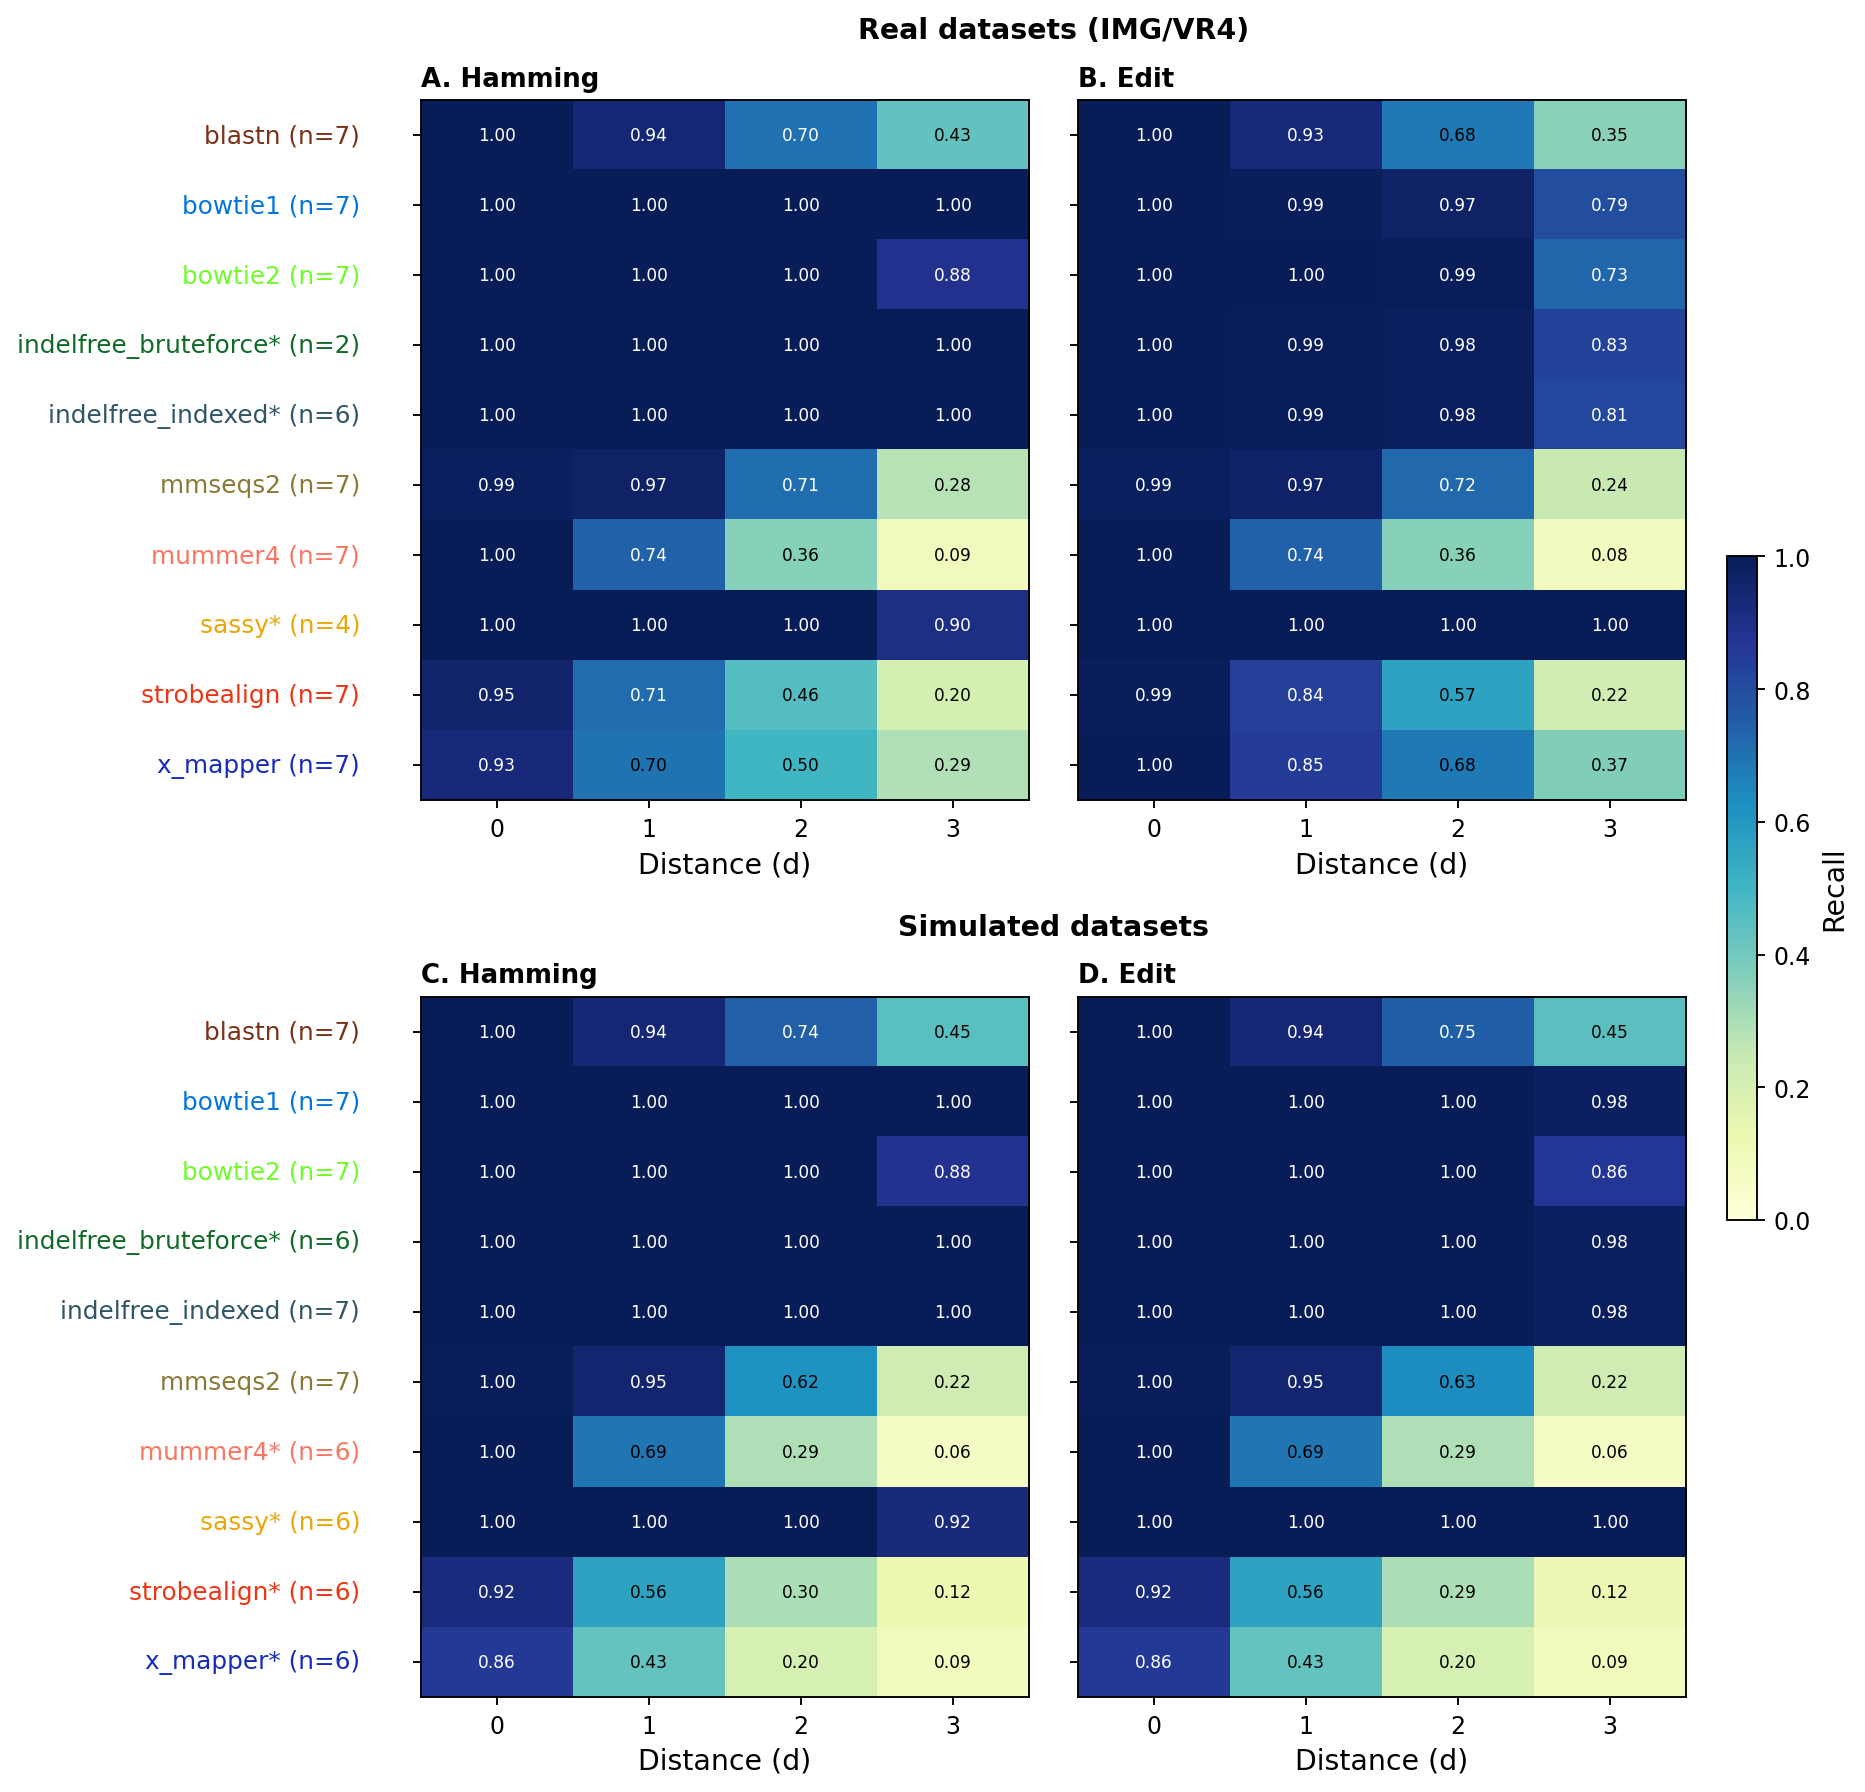

In [4]:
DIST_VALUES_COMPARE = [0, 1, 2, 3]


def _pick_table(preferred: Path, fallback: Path) -> Path:
    return preferred if preferred.exists() else fallback


real_ham_table = _pick_table(
    Path('draft/supp/figures/tables/imgvr4_hamming_exact_recall_mean_all_fractions_table.tsv'),
    Path('draft/supp/figures/tables/imgvr4_hamming_exact_recall_mean_all_fractions_table_w_minimap2.tsv'),
)
real_edit_table = _pick_table(
    Path('draft/supp/figures/tables/imgvr4_sassy_edit_exact_recall_mean_table.tsv'),
    Path('draft/supp/figures/tables/imgvr4_sassy_edit_exact_recall_mean_table_w_minimap2.tsv'),
)
sim_ham_table = _pick_table(
    Path('draft/supp/figures/tables/simulated_hamming_exact_recall_mean_all_runs_table.tsv'),
    Path('draft/supp/figures/tables/simulated_hamming_exact_recall_mean_all_runs_table_w_minimap2.tsv'),
)
sim_edit_table = _pick_table(
    Path('draft/supp/figures/tables/simulated_edit_exact_recall_mean_all_runs_table.tsv'),
    Path('draft/supp/figures/tables/simulated_edit_exact_recall_mean_all_runs_table_w_minimap2.tsv'),
)

missing = [p for p in [real_ham_table, real_edit_table, sim_ham_table, sim_edit_table] if not p.exists()]
if missing:
    print('Missing inputs (run prerequisite notebooks first):')
    for p in missing:
        print(f'  {p}')
else:
    real_ham_df = pl.read_csv(real_ham_table, separator='\t').select(['tool', 'distance', 'recall', 'n_fractions'])
    real_edit_df = pl.read_csv(real_edit_table, separator='\t').select(['tool', 'distance', 'recall'])
    sim_ham_df = pl.read_csv(sim_ham_table, separator='\t').select(['tool', 'distance', 'recall', 'n_simulations'])
    sim_edit_df = pl.read_csv(sim_edit_table, separator='\t').select(['tool', 'distance', 'recall'])

    excluded_tools = ['minimap2']
    real_ham_df = real_ham_df.filter(~pl.col('tool').is_in(excluded_tools))
    real_edit_df = real_edit_df.filter(~pl.col('tool').is_in(excluded_tools))
    sim_ham_df = sim_ham_df.filter(~pl.col('tool').is_in(excluded_tools))
    sim_edit_df = sim_edit_df.filter(~pl.col('tool').is_in(excluded_tools))

    real_tools = sorted(set(real_ham_df['tool'].unique().to_list()) | set(real_edit_df['tool'].unique().to_list()))
    sim_tools = sorted(set(sim_ham_df['tool'].unique().to_list()) | set(sim_edit_df['tool'].unique().to_list()))

    real_ham_runs = {
        r['tool']: int(r['n_fractions'])
        for r in (
            real_ham_df.group_by('tool').agg(pl.col('n_fractions').max().alias('n_fractions'))
            .iter_rows(named=True)
        )
    }
    sim_ham_runs = {
        r['tool']: int(r['n_simulations'])
        for r in (
            sim_ham_df.group_by('tool').agg(pl.col('n_simulations').max().alias('n_simulations'))
            .iter_rows(named=True)
        )
    }

    total_real_ham_runs = max(real_ham_runs.values()) if real_ham_runs else 0
    total_sim_ham_runs = max(sim_ham_runs.values()) if sim_ham_runs else 0

    def _build_matrix(df: pl.DataFrame, tools_list: list[str], dist_values: list[int]) -> np.ndarray:
        mat = np.full((len(tools_list), len(dist_values)), np.nan)
        for i, tool in enumerate(tools_list):
            td = df.filter(pl.col('tool') == tool)
            for j, d in enumerate(dist_values):
                row = td.filter(pl.col('distance') == d)
                if row.height > 0:
                    mat[i, j] = row['recall'][0]
        return mat

    real_ham_mat = _build_matrix(real_ham_df, real_tools, DIST_VALUES_COMPARE)
    real_edit_mat = _build_matrix(real_edit_df, real_tools, DIST_VALUES_COMPARE)
    sim_ham_mat = _build_matrix(sim_ham_df, sim_tools, DIST_VALUES_COMPARE)
    sim_edit_mat = _build_matrix(sim_edit_df, sim_tools, DIST_VALUES_COMPARE)

    cmap = plt.cm.YlGnBu
    cmap.set_bad(color='#cccccc')

    row_h_real = max(4.2, len(real_tools) * 0.44 + 1.1)
    row_h_sim = max(4.2, len(sim_tools) * 0.44 + 1.1)

    fig = plt.figure(figsize=(12, row_h_real + row_h_sim + 1.2), dpi=170)
    gs = fig.add_gridspec(
        nrows=2,
        ncols=2,
        width_ratios=[1, 1],
        height_ratios=[row_h_real, row_h_sim],
        hspace=0.28,
        wspace=0.08,
    )

    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]),
        fig.add_subplot(gs[1, 1]),
    ]

    panel_specs = [
        (axes[0], real_ham_mat, real_tools, real_ham_runs, total_real_ham_runs, 'A.', 'Hamming', True),
        (axes[1], real_edit_mat, real_tools, real_ham_runs, total_real_ham_runs, 'B.', 'Edit', False),
        (axes[2], sim_ham_mat, sim_tools, sim_ham_runs, total_sim_ham_runs, 'C.', 'Hamming', True),
        (axes[3], sim_edit_mat, sim_tools, sim_ham_runs, total_sim_ham_runs, 'D.', 'Edit', False),
    ]

    im_last = None
    for ax, mat, tools, run_map, total_runs, plabel, title, show_tool_labels in panel_specs:
        im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
        im_last = im
        ax.set_xticks(range(len(DIST_VALUES_COMPARE)))
        ax.set_xticklabels([str(d) for d in DIST_VALUES_COMPARE])
        ax.set_xlabel('Distance (d)')
        ax.set_yticks(range(len(tools)))
        ax.set_yticklabels([])

        if show_tool_labels:
            for i, tool in enumerate(tools):
                color = tool_colors.get(tool, '#000000')
                n_runs = run_map.get(tool, 0)
                suffix = '*' if (total_runs > 0 and n_runs < total_runs) else ''
                label = f"{tool}{suffix} (n={n_runs})"
                ax.text(
                    -0.1, i, label,
                    ha='right', va='center',
                    color=color, fontsize=10.5,
                    transform=ax.get_yaxis_transform(),
                )

        for i in range(len(tools)):
            for j in range(len(DIST_VALUES_COMPARE)):
                v = mat[i, j]
                if not np.isnan(v):
                    ax.text(
                        j, i, f'{v:.2f}',
                        ha='center', va='center',
                        fontsize=7.2,
                        color='black' if v < 0.7 else 'white',
                    )

        ax.set_title(f'{plabel} {title}', loc='left', fontsize=11, fontweight='bold')

    fig.subplots_adjust(left=0.30, right=0.92)

    top_left = axes[0].get_position()
    top_right = axes[1].get_position()
    bottom_left = axes[2].get_position()
    bottom_right = axes[3].get_position()

    top_x = (top_left.x0 + top_right.x1) / 2
    bottom_x = (bottom_left.x0 + bottom_right.x1) / 2

    row_title_pad = 0.027
    fig.text(top_x, top_left.y1 + row_title_pad, 'Real datasets (IMG/VR4)', ha='center', va='bottom', fontsize=12, fontweight='bold')
    fig.text(bottom_x, bottom_left.y1 + row_title_pad, 'Simulated datasets', ha='center', va='bottom', fontsize=12, fontweight='bold')

    if im_last is not None:
        cbar_height = 0.32
        cbar_bottom = 0.34
        cax = fig.add_axes([0.94, cbar_bottom, 0.015, cbar_height])
        fig.colorbar(im_last, cax=cax, label='Recall')

    save_combined_figure(fig, 'heatmap_real_and_sim_hamming_edit_grid', [MAIN_FIG_DIR])
    plt.show()
    plt.close(fig)

## 3. Presence Check for All Expected Manuscript Figures

Verify all figures that should exist in `draft/main/figures/` and `draft/supp/figures/` before
submitting. Add new expected filenames here as notebooks are updated.


In [23]:
expected_main = [
    # from Performance_imgvr4_v3
    'imgvr4_cross_fraction_consistency.svg',
    'imgvr4_fraction1_hamming_recall.svg',
    'imgvr4_heatmap_hamming_vs_edit.svg',
    # from Resource_usage_v2
    'resource_usage/resource_usage_cpu_2panel.svg',
    # combined (this notebook)
    'cross_fraction_recall_real_vs_sim.svg',
    'heatmap_hamming_real_vs_sim.svg',
]
expected_supp = [
    # from Performance_imgvr4_v3
    'imgvr4_cross_fraction_consistency_w_minimap2.svg',
    'imgvr4_fraction1_hamming_recall_w_minimap2.svg',
    'imgvr4_sassy_fractions_edit_recall.svg',
    'imgvr4_sassy_fractions_edit_recall_w_minimap2.svg',
    'imgvr4_heatmap_hamming_vs_edit_w_minimap2.svg',
    'imgvr4_fraction1_tool_comparison_matrix.svg',
    'imgvr4_fraction1_tool_comparison_matrix_w_minimap2.svg',
    'imgvr4_fraction1_recall_vs_occurrence.svg',
    'imgvr4_fraction1_recall_vs_occurrence_w_minimap2.svg',
    'imgvr4_high_ins_recall_vs_occurrence.svg',
    'imgvr4_high_ins_recall_vs_occurrence_w_minimap2.svg',
    'imgvr4_distribution_analysis.svg',
    # from Resource_usage_v2
    'resource_usage/resource_usage_memory_2panel.svg',
]

print("Main figures:")
for f in expected_main:
    p = MAIN_FIG_DIR / f
    status = "OK" if p.exists() else "MISSING"
    print(f" {p} [{status}] {f}")

print("\nSupplementary figures:")
for f in expected_supp:
    p = SUPP_FIG_DIR / f
    status = "OK" if p.exists() else "MISSING"
    print(f"  [{status}] {f}")


Main figures:
 draft/main/figures/imgvr4_cross_fraction_consistency.svg [MISSING] imgvr4_cross_fraction_consistency.svg
 draft/main/figures/imgvr4_fraction1_hamming_recall.svg [MISSING] imgvr4_fraction1_hamming_recall.svg
 draft/main/figures/imgvr4_heatmap_hamming_vs_edit.svg [MISSING] imgvr4_heatmap_hamming_vs_edit.svg
 draft/main/figures/resource_usage/resource_usage_cpu_2panel.svg [OK] resource_usage/resource_usage_cpu_2panel.svg
 draft/main/figures/cross_fraction_recall_real_vs_sim.svg [OK] cross_fraction_recall_real_vs_sim.svg
 draft/main/figures/heatmap_hamming_real_vs_sim.svg [OK] heatmap_hamming_real_vs_sim.svg

Supplementary figures:
  [MISSING] imgvr4_cross_fraction_consistency_w_minimap2.svg
  [MISSING] imgvr4_fraction1_hamming_recall_w_minimap2.svg
  [MISSING] imgvr4_sassy_fractions_edit_recall.svg
  [MISSING] imgvr4_sassy_fractions_edit_recall_w_minimap2.svg
  [MISSING] imgvr4_heatmap_hamming_vs_edit_w_minimap2.svg
  [MISSING] imgvr4_fraction1_tool_comparison_matrix.svg
  

## Rebuild Supplementary Tables

Generate manuscript-ready tables directly from the source sequences so CSV/TSV exports stay synchronized with the text. Tables are written to `draft/supp/figures/tables` with both legacy filenames and numbered supplementary variants (e.g., `supp_table_S4_*`).

In [7]:
from pathlib import Path
import polars as pl
from bench.utils.functions import get_seq_stats_pl

TABLE_DIR = Path('draft/supp/figures/tables')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

def build_real_dataset_sequence_stats() -> pl.DataFrame:
    results_base = Path('results/real_data/subsamples')
    spacers_file = results_base / 'fraction_1' / 'subsampled_data' / 'iphop_filtered_spacers.fna'
    rows: list[pl.DataFrame] = []

    if spacers_file.exists():
        rows.append(
            get_seq_stats_pl(str(spacers_file)).with_columns(
                pl.lit('spacers').alias('type'),
                pl.lit('all_spacers').alias('name'),
            )
        )
    else:
        print(f'Missing spacers file: {spacers_file}')

    for fraction_dir in sorted(results_base.glob('fraction_*'), key=lambda p: float(p.name.split('_')[1])):
        contig_file = fraction_dir / 'subsampled_data' / 'subsampled_contigs.fa'
        if not contig_file.exists():
            print(f'Missing contig file for {fraction_dir.name}, skipping')
            continue
        rows.append(
            get_seq_stats_pl(str(contig_file)).with_columns(
                pl.lit('contigs').alias('type'),
                pl.lit(fraction_dir.name).alias('name'),
            )
        )

    if not rows:
        raise RuntimeError('No sequence stats computed')

    df = pl.concat(rows, how='vertical_relaxed')
    df.write_csv('results/real_data/all_sequence_stats.csv')
    df.write_csv(TABLE_DIR / 'real_dataset_sequence_stats.tsv', separator='\t')
    df.write_csv(TABLE_DIR / 'real_dataset_sequence_stats.csv')
    df.write_csv(TABLE_DIR / 'supp_table_S4_real_dataset_sequence_stats.tsv', separator='\t')
    df.write_csv(TABLE_DIR / 'supp_table_S4_real_dataset_sequence_stats.csv')
    return df

seq_stats_df = build_real_dataset_sequence_stats()
display(seq_stats_df)

# Quick consistency check for fraction_1 totals
fraction1 = seq_stats_df.filter(pl.col('name') == 'fraction_1')
if fraction1.height == 1:
    n = fraction1['n_seqs'][0]
    mean = fraction1['avg_length'][0]
    total = fraction1['sum_length'][0]
    print(f'fraction_1 sum check: n*mean={n*mean:.0f} vs sum={total}')

print(f"""files saved:
      1. results/real_data/all_sequence_stats.csv
      2. {TABLE_DIR / 'real_dataset_sequence_stats.tsv'}
      3. {TABLE_DIR / 'real_dataset_sequence_stats.csv'}
      4. {TABLE_DIR / 'supp_table_S4_real_dataset_sequence_stats.tsv'}
      5. {TABLE_DIR / 'supp_table_S4_real_dataset_sequence_stats.csv'}
      """)

file,n_seqs,median_length,avg_length,sum_length,min_length,max_length,gc_frac_mean,type,name
str,i64,f64,f64,i64,i64,i64,f64,str,str
"""results/real_data/subsamples/fraction_1/subsampled_data/iphop_filtered_spacers.fna""",3826979,34.0,33.837148,129494053,25,40,0.476138,"""spacers""","""all_spacers"""
"""results/real_data/subsamples/fraction_0.0005/subsampled_data/subsampled_contigs.fa""",279,15818.0,25220.756272,7036591,1060,233373,0.480385,"""contigs""","""fraction_0.0005"""
"""results/real_data/subsamples/fraction_0.001/subsampled_data/subsampled_contigs.fa""",421,14902.0,23148.862233,9745671,1700,246318,0.480044,"""contigs""","""fraction_0.001"""
"""results/real_data/subsamples/fraction_0.005/subsampled_data/subsampled_contigs.fa""",2107,16000.0,27080.878975,57059412,1060,618736,0.472457,"""contigs""","""fraction_0.005"""
"""results/real_data/subsamples/fraction_0.01/subsampled_data/subsampled_contigs.fa""",4214,18655.0,29347.002848,123668270,1060,482156,0.472951,"""contigs""","""fraction_0.01"""
"""results/real_data/subsamples/fraction_0.05/subsampled_data/subsampled_contigs.fa""",21071,34591.0,33936.36097,715073062,1060,505259,0.474327,"""contigs""","""fraction_0.05"""
"""results/real_data/subsamples/fraction_0.1/subsampled_data/subsampled_contigs.fa""",42143,36154.0,35700.747835,1504536616,1060,596785,0.474809,"""contigs""","""fraction_0.1"""
"""results/real_data/subsamples/fraction_1/subsampled_data/subsampled_contigs.fa""",421431,40550.0,44777.539355,18870643188,1060,711471,0.475461,"""contigs""","""fraction_1"""


fraction_1 sum check: n*mean=18870643188 vs sum=18870643188
files saved:
      1. results/real_data/all_sequence_stats.csv
      2. draft/supp/figures/tables/real_dataset_sequence_stats.tsv
      3. draft/supp/figures/tables/real_dataset_sequence_stats.csv
      4. draft/supp/figures/tables/supp_table_S4_real_dataset_sequence_stats.tsv
      5. draft/supp/figures/tables/supp_table_S4_real_dataset_sequence_stats.csv
      


## Bulk TSV→CSV exports for tables
Convert every TSV in `draft/supp/figures/tables` to a CSV sibling, and optionally emit numbered `supp_table_` copies when a pattern is known. Run after upstream notebooks regenerate their TSVs.

In [9]:
from typing import Iterable
import shutil

def tsv_to_csv(tsv_path: Path, csv_path: Path) -> None:
    df = pl.read_csv(tsv_path, separator='\t')
    df.write_csv(csv_path)

def bulk_export_tables(table_dir: Path, numbered_overrides: dict[str, Iterable[str]] | None = None) -> list[tuple[Path, Path]]:
    table_dir.mkdir(parents=True, exist_ok=True)
    written: list[tuple[Path, Path]] = []
    for tsv in sorted(table_dir.glob('*.tsv')):
        csv = tsv.with_suffix('.csv')
        tsv_to_csv(tsv, csv)
        written.append((tsv, csv))

        stem = tsv.stem
        if numbered_overrides and stem in numbered_overrides:
            for target_stem in numbered_overrides[stem]:
                target_tsv = table_dir / f"{target_stem}.tsv"
                target_csv = table_dir / f"{target_stem}.csv"
                shutil.copyfile(tsv, target_tsv)
                tsv_to_csv(tsv, target_csv)
                written.append((target_tsv, target_csv))
    return written

# Known mappings to emit numbered copies (extend as needed)
NUMBERED_MAP = {
    # S4 real/sim sequence stats already generated elsewhere
    'real_dataset_sequence_stats': ['supp_table_S4_real_dataset_sequence_stats'],
    'simulated_dataset_sequence_stats': ['supp_table_S4_simulated_dataset_sequence_stats'],
}

written_pairs = bulk_export_tables(TABLE_DIR, NUMBERED_MAP)
print(f"Converted {len(written_pairs)} TSV→CSV pairs")
for tsv, csv in written_pairs:
    print(f"  {tsv} -> {csv}")

Converted 43 TSV→CSV pairs
  draft/supp/figures/tables/imgvr4_across_fractions_recall_consistency_stats_hamming_le3.tsv -> draft/supp/figures/tables/imgvr4_across_fractions_recall_consistency_stats_hamming_le3.csv
  draft/supp/figures/tables/imgvr4_across_fractions_recall_stats_hamming_le3.tsv -> draft/supp/figures/tables/imgvr4_across_fractions_recall_stats_hamming_le3.csv
  draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming0.tsv -> draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming0.csv
  draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming1.tsv -> draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming1.csv
  draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming2.tsv -> draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming2.csv
  draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming3.tsv -> draft/supp/figures/tables/imgvr4_fraction1_comparison_matrix_hamming3.csv
  draft/sup

## Coverage check: standalone table files for all manuscript tables
Ensure each table in main text and supplementary has at least one exported file (TSV or CSV) under `draft/supp/figures/tables`. Update the mapping below if table filenames change.

In [14]:
EXPECTED_TABLES = {
    # Supplementary
    'supp_table_S1_tool_config': ['supp_table_S1_tool_config.tsv', 'supp_table_S1_tool_config.csv'],
    'supp_table_S2_contig_stats': ['supp_table_S2_contig_stats.tsv', 'supp_table_S2_contig_stats.csv'],
    'supp_table_S3_spacer_stats': ['supp_table_S3_spacer_stats.tsv', 'supp_table_S3_spacer_stats.csv'],
    'supp_table_S4_real_dataset_sequence_stats': [
        'supp_table_S4_real_dataset_sequence_stats.tsv',
        'supp_table_S4_real_dataset_sequence_stats.csv',
        'real_dataset_sequence_stats.tsv',
        'real_dataset_sequence_stats.csv',
    ],
    'supp_table_S4_simulated_dataset_sequence_stats': [
        'supp_table_S4_simulated_dataset_sequence_stats.tsv',
        'supp_table_S4_simulated_dataset_sequence_stats.csv',
        'simulated_dataset_sequence_stats.tsv',
        'simulated_dataset_sequence_stats.csv',
    ],
    'supp_table_S5_prepare_jobs': ['supp_table_S5_prepare_jobs.tsv', 'supp_table_S5_prepare_jobs.csv'],
    'supp_table_S6_recall_values': ['supp_table_S6_recall_values.tsv', 'supp_table_S6_recall_values.csv'],
    # Main text tables (add here if present)
}

def ensure_table_files(table_dir: Path, expected: dict[str, list[str]]):
    missing: list[str] = []
    for label, candidates in expected.items():
        found = False
        for fname in candidates:
            if (table_dir / fname).exists():
                found = True
                print(pl.read_csv(table_dir / fname, separator='\t'))  # quick sanity check)
                break
        if not found:
            missing.append(f"{label}: {candidates}")
    if missing:
        print("Missing table exports (provide TSV or CSV):")
        for m in missing:
            print(f"  - {m}")
    else:
        print("All expected tables have at least one exported TSV/CSV file.")

ensure_table_files(TABLE_DIR, EXPECTED_TABLES)

shape: (11, 3)
┌────────────────────────┬─────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│  Tool                  ┆  Version        ┆  Command                                                                                                                        

## Extract markdown-defined tables from supplementary.qmd
Parse the markdown tables (S1, S2, S3, S5, S6) directly from `draft/supp/supplementary.qmd` and emit standalone TSV/CSV files into `draft/supp/figures/tables`. This provides a fallback when tables are authored in Quarto rather than generated from data files.

In [10]:
import io
import re

SUPP_QMD = Path('draft/supp/supplementary.qmd')
MARKDOWN_TABLES = {
    'supp_table_S1_tool_config': '### Supplementary Table S1: Tool Configuration Details',
    'supp_table_S2_contig_stats': '### Supplementary Table S2: IMG/VR4 Contig Dataset Statistics and Filtering Steps',
    'supp_table_S3_spacer_stats': '### Supplementary Table S3: CRISPR Spacer Dataset Composition and Statistics',
    'supp_table_S5_prepare_jobs': '### Supplementary Table S5: Simulation and job-generation configuration from `Prepare_all_jobs.ipynb`',
    'supp_table_S6_recall_values': '### Supplementary Table S6: Recall Values for Each Tool at Different Mismatch Thresholds',
}

def extract_markdown_table(qmd_path: Path, heading: str) -> list[str]:
    lines = qmd_path.read_text().splitlines()
    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith(heading):
            start_idx = i
            break
    if start_idx is None:
        return []
    table_lines: list[str] = []
    for line in lines[start_idx+1:]:
        if not line.strip():
            if table_lines:
                break
            else:
                continue
        if line.strip().startswith('|'):
            table_lines.append(line.strip())
        elif table_lines:
            break
    return table_lines

def markdown_table_to_polars(table_lines: list[str]) -> pl.DataFrame:
    if not table_lines:
        return pl.DataFrame()
    cleaned = []
    for ln in table_lines:
        if re.fullmatch(r"\|?[:\-\s\|]+\|?", ln):
            continue  # skip separator row
        cleaned.append(ln.strip('|'))
    text = "\n".join(cleaned)
    # Polars will create an extra empty col if trailing pipes exist; cleaned avoids that
    df = pl.read_csv(io.StringIO(text), separator='|')
    return df

def export_markdown_tables(table_dir: Path, table_map: dict[str, str]) -> list[Path]:
    written: list[Path] = []
    for stem, heading in table_map.items():
        lines = extract_markdown_table(SUPP_QMD, heading)
        df = markdown_table_to_polars(lines)
        if df.is_empty():
            print(f"Warning: no table found for heading: {heading}")
            continue
        tsv_path = table_dir / f"{stem}.tsv"
        csv_path = table_dir / f"{stem}.csv"
        df.write_csv(tsv_path, separator='\t')
        df.write_csv(csv_path)
        written.extend([tsv_path, csv_path])
    return written

written_md_tables = export_markdown_tables(TABLE_DIR, MARKDOWN_TABLES)
print(f"Markdown-derived tables written: {len(written_md_tables)} files")
for p in written_md_tables:
    print(f"  {p}")

Markdown-derived tables written: 10 files
  draft/supp/figures/tables/supp_table_S1_tool_config.tsv
  draft/supp/figures/tables/supp_table_S1_tool_config.csv
  draft/supp/figures/tables/supp_table_S2_contig_stats.tsv
  draft/supp/figures/tables/supp_table_S2_contig_stats.csv
  draft/supp/figures/tables/supp_table_S3_spacer_stats.tsv
  draft/supp/figures/tables/supp_table_S3_spacer_stats.csv
  draft/supp/figures/tables/supp_table_S5_prepare_jobs.tsv
  draft/supp/figures/tables/supp_table_S5_prepare_jobs.csv
  draft/supp/figures/tables/supp_table_S6_recall_values.tsv
  draft/supp/figures/tables/supp_table_S6_recall_values.csv


In [15]:
from pathlib import Path
import shutil

# Copy manuscript-linked figures/tables into organized export folders with informative names
root = Path('draft')
main_fig_dst = root / 'main_figures'
supp_fig_dst = root / 'supp_figures'
main_tab_dst = root / 'main_tables'
supp_tab_dst = root / 'supp_tables'
with_mm_dst = root / 'with_minimap2'
for d in [main_fig_dst, supp_fig_dst, main_tab_dst, supp_tab_dst, with_mm_dst]:
    d.mkdir(parents=True, exist_ok=True)

copy_map = [
    # Main text figures
    ('draft/main/figures/search_space_background_normalization.svg', main_fig_dst / 'fig1_background_nonplanned_normalization.svg'),
    ('draft/main/figures/heatmap_real_and_sim_hamming_edit_grid.svg', main_fig_dst / 'fig2_tool_recall_heatmap_hamming_edit.svg'),
    ('draft/main/figures/resource_usage/resource_usage_cpu_2panel.svg', main_fig_dst / 'fig3_cpu_time_scaling.svg'),
    # Supplementary figures (S1-S9)
    ('draft/supp/figures/performance/imgvr4_fraction1_tool_comparison_matrix.svg', supp_fig_dst / 'figS1_imgvr4_tool_comparison_matrix.svg'),
    ('draft/supp/figures/performance/imgvr4_high_ins_recall_vs_occurrence.svg', supp_fig_dst / 'figS2_sim_high_ins_recall_vs_occurrence.svg'),
    ('draft/supp/figures/performance/imgvr4_fraction1_recall_vs_occurrence.png', supp_fig_dst / 'figS3_imgvr4_fraction1_recall_vs_occurrence.png'),
    ('draft/supp/figures/supp/filtered_iphop_spacers_attribute_distributions_multiplot.png', supp_fig_dst / 'figS4_real_spacer_attributes.png'),
    ('draft/supp/figures/supp/simulated_spacer_distributions.svg', supp_fig_dst / 'figS4_sim_spacer_attributes.svg'),
    ('draft/supp/figures/supp/real_data_contig_distributions.svg', supp_fig_dst / 'figS5_real_contig_distributions.svg'),
    ('draft/supp/figures/supp/fraction_1_matched_spacers_distributions.png', supp_fig_dst / 'figS6_fraction1_matched_spacer_distributions.png'),
    ('draft/supp/figures/resource_usage/resource_usage_memory_2panel.svg', supp_fig_dst / 'figS7_peak_memory_scaling.svg'),
    ('draft/supp/figures/performance/imgvr4_across_fractions_recall_consistency_hamming_le3.svg', supp_fig_dst / 'figS8_imgvr4_recall_consistency.svg'),
    ('draft/supp/figures/performance/simulated_cross_fraction_consistency.svg', supp_fig_dst / 'figS8_sim_recall_consistency.svg'),
    ('draft/supp/figures/performance/simulated_heatmap_dataset_consistency_hamming_le3.svg', supp_fig_dst / 'figS8_sim_recall_heatmap.svg'),
    ('draft/supp/figures/ns_50000_nc_5000_background_counts_foldchange.svg', supp_fig_dst / 'figS9a_nonplanned_counts_ns50000.svg'),
    ('draft/supp/figures/ns_75000_nc_5000_background_counts_foldchange.svg', supp_fig_dst / 'figS9b_nonplanned_counts_ns75000.svg'),
    ('draft/supp/figures/ns_100000_nc_10000_background_counts_foldchange.svg', supp_fig_dst / 'figS9c_nonplanned_counts_ns100000.svg'),
    ('draft/supp/figures/ns_100000_nc_20000_background_counts_foldchange.svg', supp_fig_dst / 'figS9d_nonplanned_counts_ns100000_nc20000.svg'),
    # Supplementary tables (S1-S6)
    ('draft/supp/figures/tables/supp_table_S1_tool_config.tsv', supp_tab_dst / 'tabS1_tool_config.tsv'),
    ('draft/supp/figures/tables/supp_table_S2_contig_stats.tsv', supp_tab_dst / 'tabS2_contig_stats.tsv'),
    ('draft/supp/figures/tables/supp_table_S3_spacer_stats.tsv', supp_tab_dst / 'tabS3_spacer_stats.tsv'),
    ('draft/supp/figures/tables/supp_table_S4_real_dataset_sequence_stats.tsv', supp_tab_dst / 'tabS4_real_dataset_stats.tsv'),
    ('draft/supp/figures/tables/supp_table_S4_simulated_dataset_sequence_stats.tsv', supp_tab_dst / 'tabS4_simulated_dataset_stats.tsv'),
    ('draft/supp/figures/tables/supp_table_S5_prepare_jobs.tsv', supp_tab_dst / 'tabS5_prepare_jobs.tsv'),
    ('draft/supp/figures/tables/supp_table_S6_recall_values.tsv', supp_tab_dst / 'tabS6_recall_values.tsv'),
]

mm_map = [
    ('draft/supp/figures/performance/imgvr4_across_fractions_recall_consistency_hamming_le3_w_minimap2.svg', with_mm_dst / 'figS8_imgvr4_recall_consistency_w_minimap2.svg'),
    ('draft/supp/figures/performance/simulated_cross_fraction_consistency_w_minimap2.svg', with_mm_dst / 'figS8_sim_recall_consistency_w_minimap2.svg'),
    ('draft/supp/figures/performance/simulated_heatmap_dataset_consistency_hamming_le3_w_minimap2.svg', with_mm_dst / 'figS8_sim_recall_heatmap_w_minimap2.svg'),
    ('draft/supp/figures/performance/imgvr4_high_ins_recall_vs_occurrence_w_minimap2.svg', with_mm_dst / 'figS2_sim_high_ins_recall_vs_occurrence_w_minimap2.svg'),
    ('draft/supp/figures/performance/imgvr4_fraction1_recall_vs_occurrence_w_minimap2.svg', with_mm_dst / 'figS3_imgvr4_fraction1_recall_vs_occurrence_w_minimap2.svg'),
    ('draft/supp/figures/performance/imgvr4_fraction1_tool_comparison_matrix_w_minimap2.svg', with_mm_dst / 'figS1_imgvr4_tool_comparison_matrix_w_minimap2.svg'),
    ('draft/supp/figures/performance/imgvr4_heatmap_hamming_vs_edit_w_minimap2.svg', with_mm_dst / 'fig_heatmap_hamming_vs_edit_w_minimap2.svg'),
    ('draft/supp/figures/performance/simulated_heatmap_hamming_vs_edit_w_minimap2.svg', with_mm_dst / 'fig_sim_heatmap_hamming_vs_edit_w_minimap2.svg'),
    ('draft/supp/figures/resource_usage/resource_usage_cpu_time_real_vs_sim_w_minimap2.svg', with_mm_dst / 'fig_cpu_time_real_vs_sim_w_minimap2.svg'),
    ('draft/supp/figures/tables/simulated_hamming_exact_recall_mean_all_runs_table_w_minimap2.tsv', with_mm_dst / 'tab_sim_hamming_exact_recall_w_minimap2.tsv'),
    ('draft/supp/figures/tables/simulated_edit_exact_recall_mean_all_runs_table_w_minimap2.tsv', with_mm_dst / 'tab_sim_edit_exact_recall_w_minimap2.tsv'),
]

copied = []
for src, dst in copy_map + mm_map:
    src_path = Path(src)
    if not src_path.exists():
        print(f"Missing source, skipped: {src}")
        continue
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copyfile(src_path, dst)
    copied.append(dst)

print(f"Copied {len(copied)} assets to organized exports.")
for p in copied:
    print(f"  -> {p}")

Copied 36 assets to organized exports.
  -> draft/main_figures/fig1_background_nonplanned_normalization.svg
  -> draft/main_figures/fig2_tool_recall_heatmap_hamming_edit.svg
  -> draft/main_figures/fig3_cpu_time_scaling.svg
  -> draft/supp_figures/figS1_imgvr4_tool_comparison_matrix.svg
  -> draft/supp_figures/figS2_sim_high_ins_recall_vs_occurrence.svg
  -> draft/supp_figures/figS3_imgvr4_fraction1_recall_vs_occurrence.png
  -> draft/supp_figures/figS4_real_spacer_attributes.png
  -> draft/supp_figures/figS4_sim_spacer_attributes.svg
  -> draft/supp_figures/figS5_real_contig_distributions.svg
  -> draft/supp_figures/figS6_fraction1_matched_spacer_distributions.png
  -> draft/supp_figures/figS7_peak_memory_scaling.svg
  -> draft/supp_figures/figS8_imgvr4_recall_consistency.svg
  -> draft/supp_figures/figS8_sim_recall_consistency.svg
  -> draft/supp_figures/figS8_sim_recall_heatmap.svg
  -> draft/supp_figures/figS9a_nonplanned_counts_ns50000.svg
  -> draft/supp_figures/figS9b_nonplanned